In [104]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import maximum_filter

In [105]:
trybik = cv2.imread('trybik.jpg')

trybik_gray = cv2.cvtColor(trybik, cv2.COLOR_BGR2GRAY)

trybik_gray = cv2.GaussianBlur(trybik_gray, (5, 5), 0)

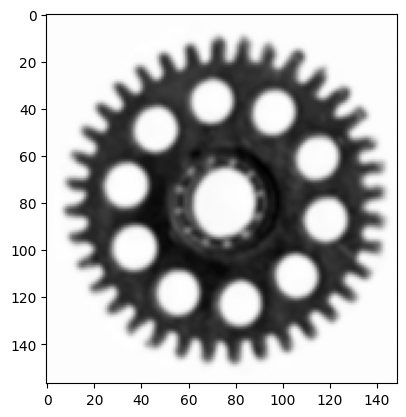

In [106]:
plt.subplot(1, 1, 1)
plt.imshow(trybik_gray, 'gray')
plt.show()

In [107]:
trybik_binarized = cv2.threshold(trybik_gray, 150, 255, cv2.THRESH_BINARY)[1]
trybik_binarized = cv2.medianBlur(trybik_binarized, 5)
trybik_binarized = cv2.bitwise_not(trybik_binarized)
contours, hierarchy = cv2.findContours(trybik_binarized, cv2.RETR_TREE, cv2.CHAIN_APPROX_NONE)
trybik_contour = cv2.drawContours(trybik, contours, 0, (255, 0, 0))

In [108]:
trybik_binarized_smooth = cv2.GaussianBlur(trybik_binarized, (3, 3), 0)
sobel_x = cv2.Sobel(trybik_binarized_smooth, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(trybik_binarized_smooth, cv2.CV_64F, 0, 1, ksize=3)

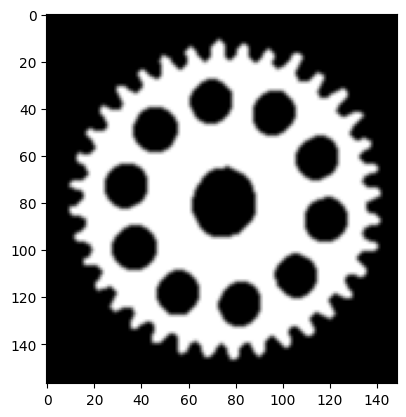

In [109]:
plt.subplot(1, 1, 1)
plt.imshow(trybik_binarized_smooth, 'gray')
plt.show()

In [110]:
amplitude = np.sqrt(sobel_x ** 2 + sobel_y ** 2)
amplitude = amplitude / np.amax(amplitude)
orientation = np.rad2deg(np.arctan2(sobel_x, sobel_y))
orientation = orientation + 180
orientation = np.uint16(orientation)
moments = cv2.moments(trybik_binarized)
center_x = int(moments['m10'] / moments['m00'])
center_y = int(moments['m01'] / moments['m00'])
r_table = [[] for _ in range(360)]

print(center_x, center_y)

76 79


In [111]:
for contour in contours[0]:
    x = contour[0][0]
    y = contour[0][1]
    angle = orientation[y, x] % 360
    vector = [x - center_x, y - center_y]
    length = np.sqrt(vector[0] ** 2 + vector[1] ** 2)
    vec_orientation = np.arctan2(vector[1], vector[0])
    r_table[angle].append([length, vec_orientation])

In [112]:
trybiki2 = cv2.imread('trybiki2.jpg')
trybiki2_gray = cv2.cvtColor(trybiki2, cv2.COLOR_BGR2GRAY)

trybiki2_gray = cv2.GaussianBlur(trybiki2_gray, (5, 5), 0)

In [113]:
sobel_x2 = cv2.Sobel(trybiki2_gray, cv2.CV_64F, 1, 0, ksize=5)
sobel_y2 = cv2.Sobel(trybiki2_gray, cv2.CV_64F, 0, 1, ksize=5)

amplitude2 = np.sqrt(sobel_x2 ** 2 + sobel_y2 ** 2)
amplitude2 = amplitude2 / np.amax(amplitude2)

In [114]:
orientation2 = np.rad2deg(np.arctan2(sobel_x2, sobel_y2))
orientation2 = orientation2 + 180
orientation2 = np.uint16(orientation2)
result = np.zeros(trybiki2_gray.shape[:2], dtype=np.uint16)

In [115]:
def filter_duplicate_points(points, min_distance=10):
    if len(points[0]) == 0:
        return points

    point_list = [(points[0][i], points[1][i]) for i in range(len(points[0]))]
    filtered_points = [point_list[0]]

    for i in range(1, len(point_list)):
        is_duplicate = False
        for filtered_point in filtered_points:
            distance = np.sqrt((point_list[i][0] - filtered_point[0]) ** 2 +
                               (point_list[i][1] - filtered_point[1]) ** 2)
            if distance < min_distance:
                is_duplicate = True
                break

        if not is_duplicate:
            filtered_points.append(point_list[i])

    filtered_x = [p[0] for p in filtered_points]
    filtered_y = [p[1] for p in filtered_points]

    return np.array(filtered_x), np.array(filtered_y)

In [116]:
for x in range(amplitude2.shape[0]):
    for y in range(amplitude2.shape[1]):
        if amplitude2[x, y] > 0.5:
            column = r_table[orientation2[x, y]]

            for r, fi in column:
                x1 = int(x + r * np.sin(fi))
                y1 = int(y + r * np.cos(fi))
                if 0 <= x1 < result.shape[0] and 0 <= y1 < result.shape[1]:
                    result[x1, y1] += 1

result = cv2.GaussianBlur(result, (9, 9), 0)

In [117]:
acc_thresh = 0.3 * np.max(result)
size = 200

local_max = (result == maximum_filter(result, size=size))
result_ = np.where((result > acc_thresh) & local_max)

result_ = filter_duplicate_points(result_, min_distance=20)

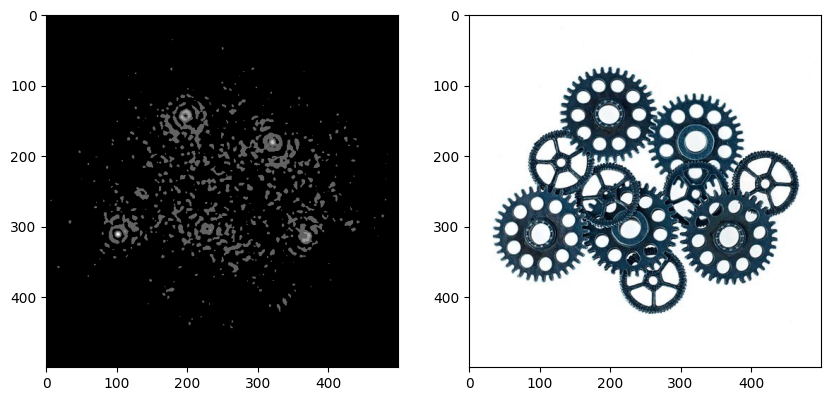

In [118]:
plt.subplots(1, 2, figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(np.log(result + 1), 'gray')

plt.subplot(1, 2, 2)
plt.imshow(trybiki2)
plt.show()

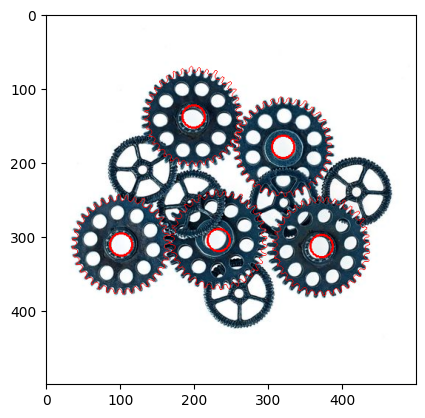

In [119]:
for i in range(len(result_[0])):
    x_, y_ = result_[0][i], result_[1][i]
    cv2.circle(trybiki2, (y_, x_), 15, (255, 0, 0), 2)
    cv2.drawContours(trybiki2, contours, 0, (255, 0, 0), offset=(y_ - center_x, x_ - center_y))

plt.imshow(trybiki2)
plt.show()